/home/felipemendez/Uni/mineria_de_datos/Proyecto2/Proyecto-2-Mineria-de-datos/.venv/lib64/python3.14/site-packages/sklearn/impute/_base.py:641: UserWarning: Skipping features without any observed values: ['Sex']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(



Procesando 10 iteraciones para: Random Forest


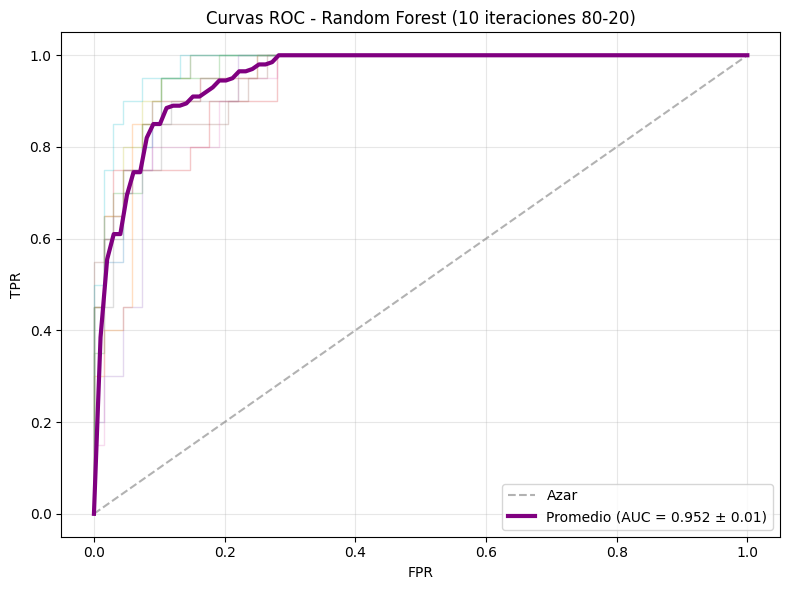


Procesando 10 iteraciones para: XGBoost


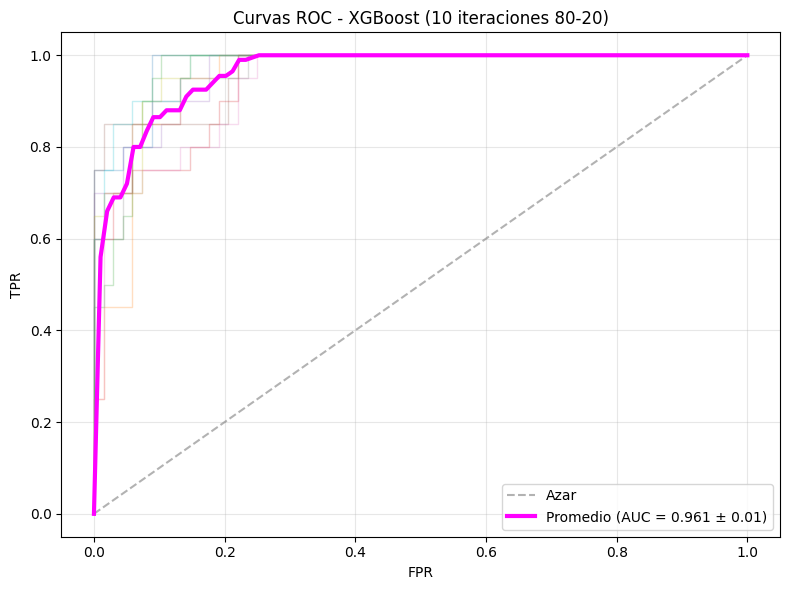


Procesando 10 iteraciones para: Reg. Logística


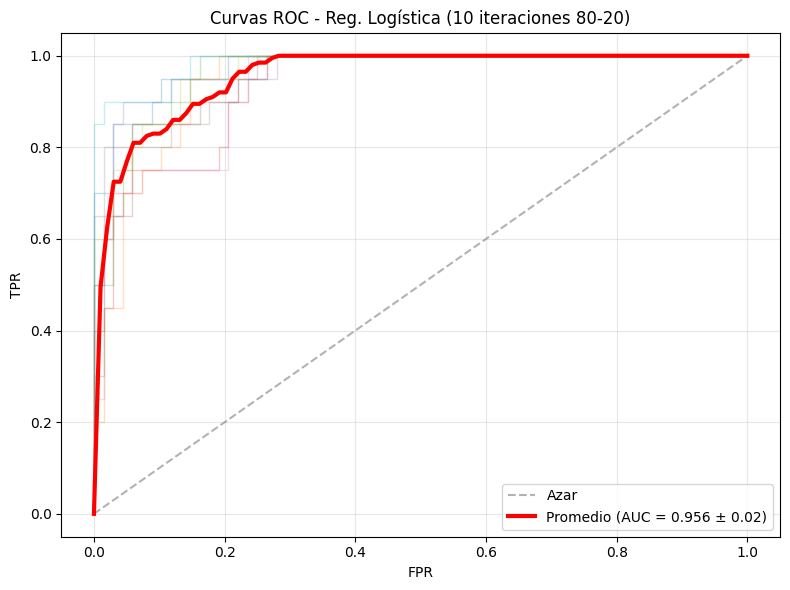

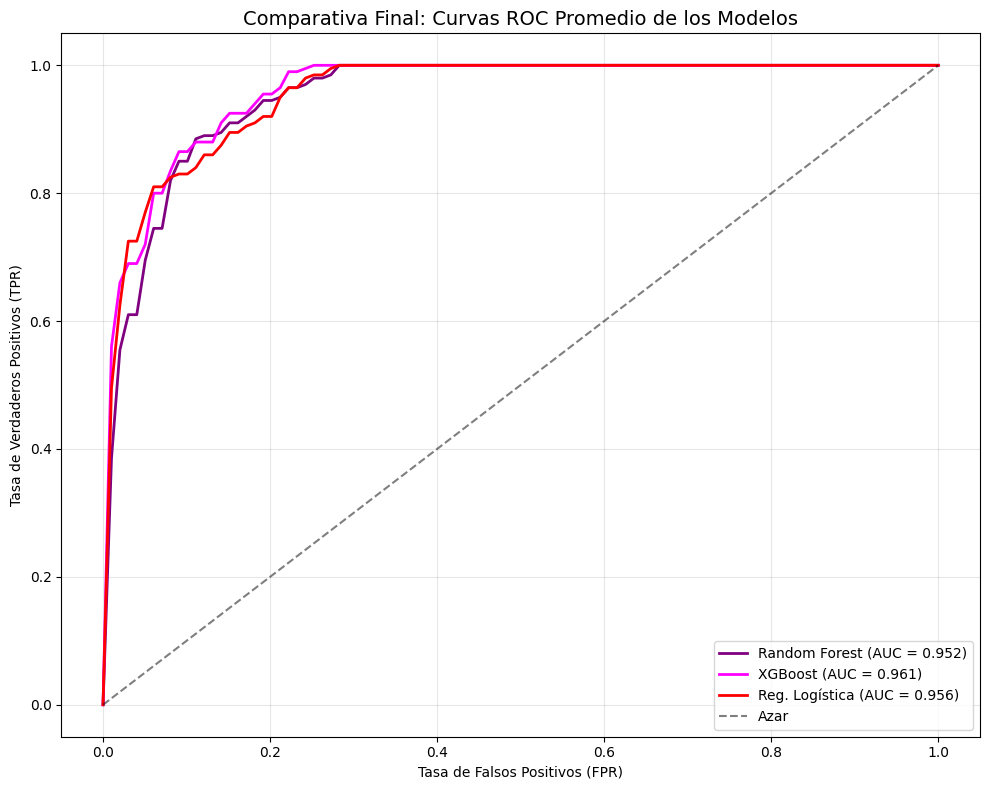

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import roc_curve, auc
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier

# 1. Preparación de datos
df = pd.read_csv('oasis_cross-sectional.csv')
features = ['Sex', 'Age', 'Educ', 'SES', 'MMSE', 'eTIV', 'nWBV', 'ASF']
X = df[features].copy()
X['Sex'] = X['Sex'].map({'M': 0, 'F': 1})

y = df['CDR'].apply(lambda x: 1 if x >= 0.5 else 0)

imputer = SimpleImputer(strategy='median')
X_prep = imputer.fit_transform(X)


def evaluar_modelo_roc(nombre, modelo, X_data, y_target, color, escalar=False):
    """Evalúa un modelo con 10 particiones 80-20 y grafica ROC individuales y promedio."""
    mean_fpr = np.linspace(0, 1, 100)
    tprs = []
    aucs = []

    fig, ax = plt.subplots(figsize=(8, 6))
    print(f"\nProcesando 10 iteraciones para: {nombre}")

    for i in range(10):
        X_train, X_test, y_train, y_test = train_test_split(
            X_data,
            y_target,
            test_size=0.20,
            random_state=i,
            stratify=y_target,
        )

        if escalar:
            scaler = StandardScaler()
            X_train = scaler.fit_transform(X_train)
            X_test = scaler.transform(X_test)

        modelo.fit(X_train, y_train)
        y_proba = modelo.predict_proba(X_test)[:, 1]
        fpr, tpr, _ = roc_curve(y_test, y_proba)
        roc_auc = auc(fpr, tpr)

        interp_tpr = np.interp(mean_fpr, fpr, tpr)
        interp_tpr[0] = 0.0
        tprs.append(interp_tpr)
        aucs.append(roc_auc)

        ax.plot(fpr, tpr, lw=1, alpha=0.25)

    mean_tpr = np.mean(tprs, axis=0)
    mean_tpr[-1] = 1.0
    mean_auc = auc(mean_fpr, mean_tpr)
    std_auc = np.std(aucs)

    ax.plot([0, 1], [0, 1], linestyle='--', color='gray', alpha=0.6, label='Azar')
    ax.plot(
        mean_fpr,
        mean_tpr,
        color=color,
        lw=3,
        label=f'Promedio (AUC = {mean_auc:.3f} ± {std_auc:.2f})',
    )
    ax.set_title(f'Curvas ROC - {nombre} (10 iteraciones 80-20)')
    ax.set_xlabel('FPR')
    ax.set_ylabel('TPR')
    ax.legend(loc='lower right')
    ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

    return mean_fpr, mean_tpr, mean_auc


# 2. Modelos a evaluar
modelos_dict = {
    'Random Forest': (
        RandomForestClassifier(
            n_estimators=100,
            max_depth=5,
            class_weight='balanced',
            random_state=42,
        ),
        'purple',
        False,
    ),
    'XGBoost': (
        XGBClassifier(
            n_estimators=100,
            max_depth=3,
            learning_rate=0.1,
            eval_metric='logloss',
            random_state=42,
        ),
        'magenta',
        False,
    ),
    'Reg. Logística': (
        LogisticRegression(
            class_weight='balanced',
            max_iter=1000,
            random_state=42,
        ),
        'red',
        True,
    ),
}

resultados_finales = {}

for nombre, (modelo, color, escalar) in modelos_dict.items():
    fpr_v, tpr_v, auc_v = evaluar_modelo_roc(nombre, modelo, X_prep, y, color, escalar=escalar)
    resultados_finales[nombre] = (fpr_v, tpr_v, auc_v, color)


# 3. Gráfico comparativo final con los promedios de todos los modelos
plt.figure(figsize=(10, 8))
for nombre, (fpr, tpr, auc_v, color) in resultados_finales.items():
    plt.plot(fpr, tpr, color=color, lw=2, label=f'{nombre} (AUC = {auc_v:.3f})')

plt.plot([0, 1], [0, 1], linestyle='--', color='black', alpha=0.5, label='Azar')
plt.title('Comparativa Final: Curvas ROC Promedio de los Modelos', fontsize=14)
plt.xlabel('Tasa de Falsos Positivos (FPR)')
plt.ylabel('Tasa de Verdaderos Positivos (TPR)')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()